### TF-TF interactions

In [140]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


import numpy as np

import re



from collections import Counter



import networkx as nx

import colorsys
import pygraphviz as pgv

import ast


from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests

from collections import defaultdict, Counter
from itertools import combinations
import random
import logging
import scipy.stats as stats

# Set PDF font type for Illustrator compatibility
plt.rcParams['pdf.fonttype'] = 42  # TrueType fonts (editable text)
plt.rcParams['ps.fonttype'] = 42   # For saving as EPS too, if needed

### Loading the interaction files with p values

In [141]:
pvalues_shuffle = pd.read_csv("TF_TF_interaction_TF_full_log2FC.csv")


In [162]:
pvalues_shuffle

,Unnamed: 0,Gene 1,Gene 2,Observed Count,Mean Null Count,log2FC
0,0,ZNF608-P1,ZNF608-P2,30,13.1085,1.194460
1,1,HMG20A-P1P2,LZTS1-P1P2,2,0.1000,4.321928
2,2,ARNT-P1P2,HIF1A-P1P2,29,13.5450,1.098293
3,3,SMAD3-P1P2,TOPORS-P1P2,2,0.1065,4.231075
4,4,HAND2-P1,LZTS1-P1P2,2,0.1007,4.311864
...,...,...,...,...,...,...
7149,7149,CC2D1A-P1P2,SOX4-P1,1,0.4122,1.278584
7150,7150,CC2D1A-P1P2,ZNF827-P1P2,1,0.0679,3.880445
7151,7151,MEF2C-P1P2,ZNF827-P1P2,1,1.0364,-0.051581
7152,7152,SOX4-P1,ZNF827-P1P2,1,1.5953,-0.673828


In [143]:
# Apply regex to clean '-P1', '-P2', or '-P1P2' only at the end of each gene name
#pvalues_shuffle['Gene_1_Clean'] = pvalues_shuffle['Gene 1'].str.replace(r'-P[12](P2)?$', '', regex=True)
#pvalues_shuffle['Gene_2_Clean'] = pvalues_shuffle['Gene 2'].str.replace(r'-P[12](P2)?$', '', regex=True)

# Create cleaned pair label
#pvalues_shuffle['Pair_Clean'] = pvalues_shuffle['Gene_1_Clean'] + ' - ' + pvalues_shuffle['Gene_2_Clean']


In [144]:

K_250 = pd.read_csv("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/TF_full_sig_perturbations_K_250_FDR_0.001_12_5_24.csv")
K_250['Program'] = K_250['Score Column'].str.split('_').str[1]

# Convert the new 'program' column to numeric if needed
K_250['Program'] = pd.to_numeric(K_250['Program'], errors='coerce')

K_250 = K_250.dropna(subset=['Program', 'Gene'])


In [145]:

subset_program = K_250.copy()

grouped = subset_program.groupby('Program')['Gene'].apply(list)
grouped_dict = grouped.to_dict()

In [146]:
def calculate_cooccurrences(data):
    cooccurrence_counts = defaultdict(int)
    for program, genes in data.items():
        for gene_pair in combinations(genes, 2):
            cooccurrence_counts[tuple(sorted(gene_pair))] += 1
    return cooccurrence_counts


In [147]:
observed_counts = calculate_cooccurrences(grouped_dict)


## Hypergeometric test for p values

In [148]:


# grouped_dict: {Program: [TF1, TF2, ...]}
# observed_counts: {(TF1, TF2): observed co-occurrence count}

N = len(grouped_dict)  # total number of programs

# TF -> set of programs containing that TF
tf_to_programs = {}

for program, tfs in grouped_dict.items():
    for tf in tfs:
        tf_to_programs.setdefault(tf, set()).add(program)

hypergeom_results = []

for pair, observed_overlap in observed_counts.items():
    tf1, tf2 = pair

    programs_tf1 = tf_to_programs[tf1]
    programs_tf2 = tf_to_programs[tf2]

    K = len(programs_tf1)   # number of programs with TF1
    n = len(programs_tf2)   # number of programs with TF2
    k = observed_overlap    # observed overlap

    expected_overlap = (K * n) / N

    # Right-tailed hypergeometric test: P(X >= k)
    p_value = hypergeom.sf(k - 1, N, K, n)

    log2_obs_exp = np.log2((k + 0.5) / (expected_overlap + 0.5))

    hypergeom_results.append({
        "Gene 1": tf1,
        "Gene 2": tf2,
        "Observed Count": k,
        "TF1 Program Count": K,
        "TF2 Program Count": n,
        "Expected Count": expected_overlap,
        "log2 Observed/Expected": log2_obs_exp,
        "Hypergeometric P Value": p_value
    })

hypergeom_df = pd.DataFrame(hypergeom_results)

hypergeom_df["Hypergeometric Adjusted P Value"] = multipletests(
    hypergeom_df["Hypergeometric P Value"],
    method="fdr_bh"
)[1]

hypergeom_df["-log10 Hypergeometric FDR"] = -np.log10(
    hypergeom_df["Hypergeometric Adjusted P Value"]
)

hypergeom_df = hypergeom_df.sort_values(
    "Hypergeometric Adjusted P Value"
).reset_index(drop=True)



In [149]:
hypergeom_df = hypergeom_df.drop(columns=["Expected Count","log2 Observed/Expected","Observed Count"])

In [158]:



merged_df = pvalues_shuffle.merge(
    hypergeom_df,
    on=["Gene 1", "Gene 2"],
    how="inner"
)








In [159]:
merged_df['Gene 1 Clean'] = merged_df['Gene 1'].str.replace(r'-P[12](P2)?$', '', regex=True)
merged_df['Gene 2 Clean'] = merged_df['Gene 2'].str.replace(r'-P[12](P2)?$', '', regex=True)
merged_df['Pair_Clean'] = merged_df['Gene 1 Clean'] + ' - ' + merged_df['Gene 2 Clean']


In [152]:
merged_df = merged_df[merged_df["Gene 1 Clean"] != merged_df["Gene 2 Clean"]]

In [161]:
#merged_df.to_csv("TF_TF_interaction_TF_full_null_fixed.csv")

In [160]:
merged_df

,Unnamed: 0,Gene 1,Gene 2,Observed Count,Mean Null Count,log2FC,TF1 Program Count,TF2 Program Count,Hypergeometric P Value,Hypergeometric Adjusted P Value,-log10 Hypergeometric FDR,Gene 1 Clean,Gene 2 Clean,Pair_Clean
0,0,ZNF608-P1,ZNF608-P2,30,13.1085,1.194460,67,30,2.343701e-19,1.676684e-15,14.775549,ZNF608,ZNF608,ZNF608 - ZNF608
1,1,HMG20A-P1P2,LZTS1-P1P2,2,0.1000,4.321928,3,2,1.129305e-04,1.170877e-02,1.931489,HMG20A,LZTS1,HMG20A - LZTS1
2,2,ARNT-P1P2,HIF1A-P1P2,29,13.5450,1.098293,39,52,1.075254e-14,3.846184e-11,10.414970,ARNT,HIF1A,ARNT - HIF1A
3,3,SMAD3-P1P2,TOPORS-P1P2,2,0.1065,4.231075,2,3,1.129305e-04,1.170877e-02,1.931489,SMAD3,TOPORS,SMAD3 - TOPORS
4,4,HAND2-P1,LZTS1-P1P2,2,0.1007,4.311864,3,2,1.129305e-04,1.170877e-02,1.931489,HAND2,LZTS1,HAND2 - LZTS1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7149,7149,CC2D1A-P1P2,SOX4-P1,1,0.4122,1.278584,1,46,1.991342e-01,2.681359e-01,0.571645,CC2D1A,SOX4,CC2D1A - SOX4
7150,7150,CC2D1A-P1P2,ZNF827-P1P2,1,0.0679,3.880445,1,4,1.731602e-02,7.086887e-02,1.149544,CC2D1A,ZNF827,CC2D1A - ZNF827
7151,7151,MEF2C-P1P2,ZNF827-P1P2,1,1.0364,-0.051581,24,4,3.571473e-01,4.135694e-01,0.383452,MEF2C,ZNF827,MEF2C - ZNF827
7152,7152,SOX4-P1,ZNF827-P1P2,1,1.5953,-0.673828,46,4,5.913026e-01,6.245650e-01,0.204422,SOX4,ZNF827,SOX4 - ZNF827


##  volcano plots for the interacting pairs

### The bipartite shuffle was run on the node


Top 2 additional pairs: ['BHLHA15 - TEAD4', 'RCOR2 - SOX11']


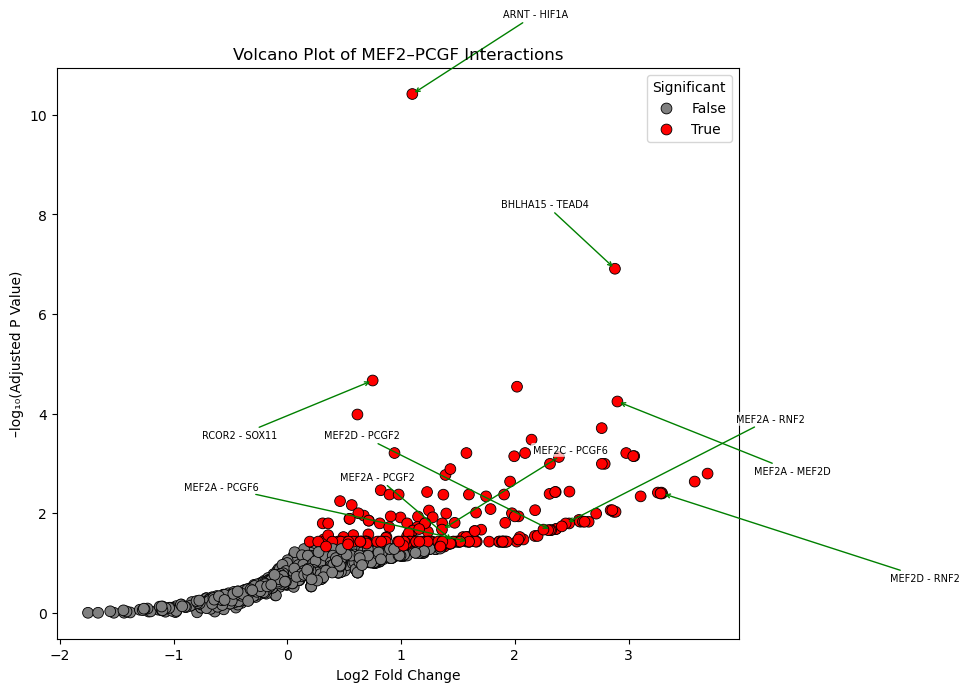

In [156]:

# Copy dataframe and drop NaNs
volcano_df = merged_df.dropna(subset=['Hypergeometric Adjusted P Value', 'log2FC']).copy()

# Compute log2 fold change, avoid log2(0)

#volcano_df['log2FC'] = np.log2(volcano_df['fold_change'].replace(0, np.nan))

volcano_df = volcano_df[volcano_df['Observed Count'] >2]

# Clean gene names
volcano_df['Gene 1 Clean'] = volcano_df['Gene 1'].str.replace(r'-P[12](P2)?$', '', regex=True)
volcano_df['Gene 2 Clean'] = volcano_df['Gene 2'].str.replace(r'-P[12](P2)?$', '', regex=True)
volcano_df['Pair_Clean'] = volcano_df['Gene 1 Clean'] + ' - ' + volcano_df['Gene 2 Clean']

# Compute -log10 adjusted p-value
volcano_df['-log10pval'] = -np.log10(volcano_df['Hypergeometric Adjusted P Value'])

# Define significance threshold
volcano_df['Significant'] = volcano_df['Hypergeometric Adjusted P Value'] < 0.05

# List of cleaned pairs to annotate
annotate_pairs = [
    'MEF2A - PCGF2',
    'ARNT - HIF1A',
    'MEF2A - PCGF6',
    'MEF2A - RNF2',
    'MEF2C - PCGF6',
    'MEF2C - RNF2',
    'MEF2D - PCGF2',
    'MEF2D - RNF2',
    'MEF2A - MEF2D'

]

# Define varied offsets for label positioning
offsets = [(0.8, 1.5), (-1.0, 1.2), (1.2, -1.5), (-1.5, -1.2), (1.5, 2), (-2, 1.8), (2, -1.8), (-2.5, 1)]





# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=volcano_df,
    x='log2FC',
    y='-log10pval',
    hue='Significant',
    palette={True: 'red', False: 'grey'},
    edgecolor='black',
    s=60
)

# Find top 2 most significant pairs not already annotated
top2_pairs = (
    volcano_df[
        ~volcano_df['Pair_Clean'].isin(annotate_pairs)
    ]
    .nsmallest(2, 'Hypergeometric Adjusted P Value')['Pair_Clean']
    .tolist()
)

print("Top 2 additional pairs:", top2_pairs)

# Annotate selected pairs with arrows
annotated_count = 0
for _, row in volcano_df.iterrows():
    if row['Pair_Clean'] in annotate_pairs or row['Pair_Clean'] in top2_pairs:

        dx, dy = offsets[annotated_count % len(offsets)]

        plt.annotate(
            row['Pair_Clean'],
            xy=(row['log2FC'], row['-log10pval']),
            xytext=(row['log2FC'] + dx, row['-log10pval'] + dy),
            arrowprops=dict(arrowstyle='->', color='green', lw=1),
            fontsize=7,
            ha='left',
            va='bottom',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
        )

        annotated_count += 1

# Aesthetics
plt.xlabel('Log2 Fold Change')
plt.ylabel('–log₁₀(Adjusted P Value)')
plt.title('Volcano Plot of MEF2–PCGF Interactions')
plt.legend(title='Significant', loc='upper right')
plt.tight_layout()
#plt.savefig("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_full_cNMF_figure_2_plots/complex_analysis_volcano_plot_greater_than_2_hypergeom.pdf")
plt.show()


##  Common programs between pairs 

#### Loading the file that has program number for each interaction

In [9]:
df_merged = pd.read_csv('/project/GCRB/Hon_lab/s438217/cNMF/TF_full/gene_program_interactions_with_program_number.csv')

In [10]:
df_merged = df_merged.drop(columns=["Unnamed: 0.1", "Unnamed: 0"], errors='ignore')

In [11]:
df_merged = df_merged[df_merged['Adjusted P Value']<0.05]

In [12]:
df_merged = df_merged[df_merged["Observed Count"]>1]

### HIF1A ARNT programs

In [13]:
HIF1_ARNT = df_merged[df_merged["Gene 1"].str.startswith("ARNT") & df_merged["Gene 2"].str.startswith("HIF1")]

In [14]:
x = HIF1_ARNT["Common_Programs"].to_list()

In [15]:
len(ast.literal_eval(x[0]))

29

## MEF2A

In [16]:

target_genes = ["PCGF2", "PCGF6", "RNF2"]

target_genes = tuple(target_genes)

In [17]:
df_mef2a = df_merged[df_merged["Gene 1"].str.startswith("MEF2A") | df_merged["Gene 2"].str.startswith("MEF2A")]

df_links = df_mef2a[
    df_mef2a["Gene 1"].str.startswith(target_genes) | df_mef2a["Gene 2"].str.startswith(target_genes)
]


In [18]:
df_links

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
1157,MEF2A-P1P2,PCGF6-P1P2,3,1.455988,0.000219,0.001355,2.060456,MEF2A,PCGF6,No interaction found,"[8, 1, 28]"
1223,MEF2A-P1P2,RNF2-P1P2,3,1.168860,0.000699,0.004088,2.566604,MEF2A,RNF2,No interaction found,"[1, 4, 5]"
1424,MEF2A-P1P2,PCGF2-P1,3,1.576419,0.004267,0.021421,1.903047,MEF2A,PCGF2,No interaction found,"[1, 4, 5]"


## MEF2C

In [19]:
df_mef2c = df_merged[df_merged["Gene 1"].str.startswith("MEF2C") | df_merged["Gene 2"].str.startswith("MEF2C")]

df_link_mef2c = df_mef2c[
    df_mef2c["Gene 1"].str.startswith(target_genes) | df_mef2c["Gene 2"].str.startswith(target_genes)
]


In [20]:
df_link_mef2c = df_link_mef2c[["Gene 1","Gene 2","Common_Programs"]]

In [21]:
df_link_mef2c

,Gene 1,Gene 2,Common_Programs
1347,MEF2C-P1P2,PCGF6-P1P2,"[1, 8, 9, 26, 28]"
1414,MEF2C-P1P2,RNF2-P1P2,"[1, 5]"


## MEF2D

In [22]:
df_mef2d = df_merged[df_merged["Gene 1"].str.startswith("MEF2D") | df_merged["Gene 2"].str.startswith("MEF2D")]

df_link_mef2d = df_mef2d[
    df_mef2d["Gene 1"].str.startswith(target_genes) | df_mef2d["Gene 2"].str.startswith(target_genes)
]


In [23]:
df_link_mef2d

,Gene 1,Gene 2,Observed Count,Mean Null Count,P Value,Adjusted P Value,fold change,clean_gene1,clean_gene2,Interaction Type (BioGrid),Common_Programs
71,MEF2D-P1P2,PCGF2-P1,3,1.222458,5.170000e-11,5.140000e-09,2.454073,MEF2D,PCGF2,No interaction found,"[1, 4, 5]"
1321,MEF2D-P1P2,RNF2-P1P2,3,1.090566,1.840233e-03,9.958418e-03,2.750865,MEF2D,RNF2,No interaction found,"[1, 4, 5]"


### Gene program terms for in the interactors

In [24]:
prog_num = [8, 28, 1, 4, 5, 9, 26]

In [25]:
GO = pd.read_csv("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/Gene_ontology_K_250.csv")

In [26]:
GO = GO[GO["Adjusted P-value"]<0.05]

In [27]:
complex_programs = GO[GO["Source"].isin(prog_num)]

In [28]:
complex_programs = (
    complex_programs
    .groupby("Source", group_keys=False)   # replace "number" with your group column name
    .apply(lambda x: x.sort_values(by="Adjusted P-value"))
)


/tmp/ipykernel_1256190/338627062.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(by="Adjusted P-value"))


In [29]:
complex_programs = complex_programs[["Gene_set","Term","Overlap","P-value","Adjusted P-value","Genes","Source"]]

In [30]:
complex_programs = complex_programs.rename(columns={"Source": "Program number"})


In [ ]:
#complex_programs.to_csv("/project/GCRB/Hon_lab/s438217/cNMF/TF_full/TF_perturb_full/GO_terms_for_MEF2_PRC_interactions.csv")